<a href="https://colab.research.google.com/github/RohitPoduval1/csci5527-project/blob/main/VGGFaceResNet50_Baseline_Stanford.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VGGFace Baseline (Stanford CS230)

## Installations/Libraries

In [9]:
# Legacy Keras and VGGFace
!pip install tf-keras
!pip install keras_vggface keras_applications
!pip install kagglehub

import os
# Force tensorflow to use the legacy keras backend
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import tensorflow as tf
import tf_keras as keras
import sys
import kagglehub

# Patch for VGGFace
sys.modules['keras.utils.data_utils'] = tf.keras.utils
sys.modules['keras.utils.layer_utils'] = tf.keras.utils
keras.utils.data_utils = tf.keras.utils
keras.utils.layer_utils = tf.keras.utils

sys.modules['keras'] = keras
sys.modules['keras.engine'] = keras.src.engine
sys.modules['keras.engine.topology'] = keras.utils

from keras_vggface.vggface import VGGFace
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

# Get dataset
dataset_path = kagglehub.dataset_download("msambare/fer2013")
print("Dataset downloaded successfully!")
print("Path to dataset files:", dataset_path)

TensorFlow Version: 2.19.0
Using Colab cache for faster access to the 'fer2013' dataset.
Dataset downloaded successfully!
Path to dataset files: /kaggle/input/fer2013


## Augmentations, Train/Test

In [10]:
train_dir = os.path.join(dataset_path, 'train')
test_dir = os.path.join(dataset_path, 'test')

# Stanford training augmentations
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Test set, no augmentations just scaling
test_datagen = ImageDataGenerator(rescale=1./255)

# Batch size 128, 197x197 images
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(197, 197),
    color_mode='rgb',
    shuffle=True,
    class_mode='categorical',
    batch_size=128
)

validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(197, 197),
    color_mode='rgb',
    shuffle=False,
    class_mode='categorical',
    batch_size=128
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


## VGG ResNet50 Transfer Learning

In [11]:
# VGGFace ResNet50 base
vggface_base = VGGFace(model='resnet50', include_top=False, input_shape=(197, 197, 3), pooling='avg')

# Freeze all conv layers, leave batch norm layers trainable
for layer in vggface_base.layers:
    if 'bn' in layer.name or 'batch_normalization' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

# Classification head
model = Sequential([
    vggface_base,
    Dropout(0.5), # pre-dense dropout

    Dense(4096, activation='relu'),
    Dropout(0.5),

    Dense(1024, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

# SGD, nesterov momentum
sgd = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

# Learning rate scheduler
rlrop = ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.5, patience=10, min_lr=0.00001, verbose=1)

model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])
print("Stanford-Replicated TensorFlow Baseline Constructed.")

Stanford-Replicated TensorFlow Baseline Constructed.


In [12]:
epochs = 100

print("Starting Baseline Training...")

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[rlrop]
)

# Save tensorflow weights
model.save('tf_stanford_resnet50_baseline.h5')
print("Model saved to tf_stanford_resnet50_baseline.h5")

Starting Baseline Training...
Epoch 1/100
225/225 [==============================] - 275s 1s/step - loss: 1.8910 - accuracy: 0.3346 - val_loss: 1.8736 - val_accuracy: 0.1718 - lr: 0.0100
Epoch 2/100
225/225 [==============================] - 261s 1s/step - loss: 1.3781 - accuracy: 0.4758 - val_loss: 2.0142 - val_accuracy: 0.1824 - lr: 0.0100
Epoch 3/100
225/225 [==============================] - 261s 1s/step - loss: 1.2742 - accuracy: 0.5220 - val_loss: 1.4339 - val_accuracy: 0.4405 - lr: 0.0100
Epoch 4/100
225/225 [==============================] - 260s 1s/step - loss: 1.2106 - accuracy: 0.5438 - val_loss: 1.0907 - val_accuracy: 0.5974 - lr: 0.0100
Epoch 5/100
225/225 [==============================] - 261s 1s/step - loss: 1.1558 - accuracy: 0.5671 - val_loss: 1.0311 - val_accuracy: 0.6165 - lr: 0.0100
Epoch 6/100
225/225 [==============================] - 262s 1s/step - loss: 1.1343 - accuracy: 0.5779 - val_loss: 1.0229 - val_accuracy: 0.6206 - lr: 0.0100
Epoch 7/100
225/225 [=======

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved to tf_stanford_resnet50_baseline.h5


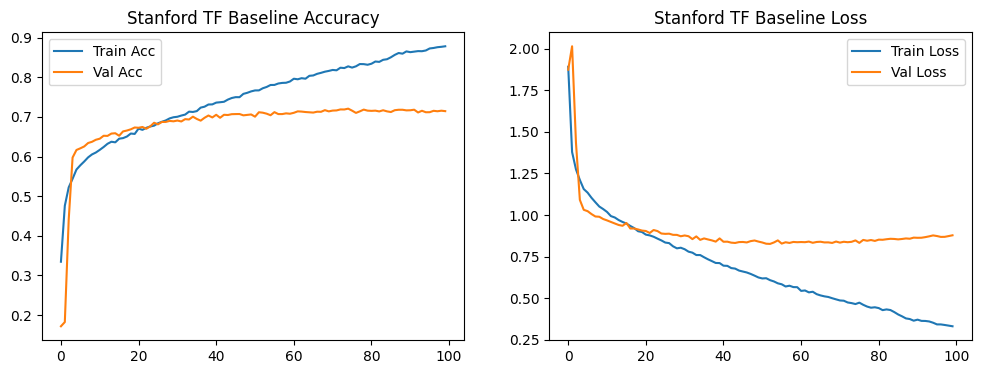

In [13]:
# Plotting the results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Stanford TF Baseline Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Stanford TF Baseline Loss')
plt.legend()
plt.show()